# Vietnamese VQA — Approach B (Multimodal Pre-trained Models)

**Bộ dữ liệu:** VQA tiếng Việt 10 món ăn (~7.5k train / ~0.9k val / ~0.9k test).

| Cấu hình | Mô hình | Chiến lược tiếng Việt | Vai trò |
|---|---|---|---|
| **B1** | `Salesforce/blip2-opt-2.7b` | **Dịch máy** Vi → En → Vi (Helsinki MarianMT) | Zero-shot |
| **B2** | `Qwen/Qwen2-VL-2B-Instruct` | **Trực tiếp tiếng Việt** (Qwen2-VL hỗ trợ đa ngôn ngữ) | Fine-tune LoRA + 4-bit (bnb) |

**Tối ưu cho Kaggle T4 ×2 (16GB ×2):**
- BLIP-2 OPT-2.7B nạp ở `float16` (~5.5 GB) → vừa 1 GPU.
- Qwen2-VL-2B nạp ở **4-bit NF4 (bnb)** (~1.7 GB) → train được trên 1 T4, dư VRAM cho batch+activations.
- LoRA r=16 trên `q_proj, k_proj, v_proj, o_proj` → ~10–15M trainable.
- Gradient checkpointing + per_device_batch=1 + grad_accum=8 → effective batch = 8.
- AMP fp16, cosine schedule, early stopping.

## Mục lục
1. **Environment Setup** — pip, imports, seed, device.
2. **Configuration** — paths (auto-detect Kaggle/local), model IDs, hyperparameters.
3. **Data Loading** — train/val/test + helper `load_image`.
4. **Evaluation Metrics** — EM, soft acc, BLEU, ROUGE-L, METEOR, BERTScore, semantic sim.
5. **LLM-as-a-Judge** — code Claude API, mặc định tắt.
6. **B1 — BLIP-2 OPT-2.7B Zero-shot** (Vi↔En)
7. **B2 — Qwen2-VL-2B + LoRA** (Vietnamese direct)
8. **So sánh B1 vs B2** — bảng, biểu đồ, định tính.
9. **Persist results** → `results_B.json` cho `VQA_Demo_Compare.ipynb`.


## 1. Environment Setup

### 1.1 Cài thư viện (chỉ chạy 1 lần trên Kaggle)

In [1]:
# Trên Kaggle: chạy 1 lần cho session. Trên local: bỏ qua nếu đã cài.
!pip install -q --no-cache-dir -U \
    "transformers>=4.57.0" \
    "accelerate>=1.0.0" \
    "peft>=0.13.2" \
    "bitsandbytes>=0.46.1" \
    "qwen-vl-utils>=0.0.8" \
    "sentencepiece>=0.2.0" \
    "nltk>=3.9.1" \
    "rouge-score>=0.1.2" \
    "bert-score>=0.3.13" \
    "sentence-transformers>=3.2.1" \
    "openai>=1.0.0"
!python -c "import nltk; nltk.download('wordnet', quiet=True); nltk.download('omw-1.4', quiet=True); nltk.download('punkt', quiet=True)"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 42.0 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 380.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.7/680.7 kB 352.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 71.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 377.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 300.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 588.7/588.7 kB 327.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 362.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.6/663.6 kB 407.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 70.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 87.4 MB/s eta 0:00:00ta 0:00:01


### 1.2 Imports & utilities

In [2]:
import gc, json, os, platform, random, re, warnings
from collections import Counter
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset

warnings.filterwarnings("ignore")

def set_seed(seed: int = 42) -> None:
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
set_seed(42)

DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_WORKERS = 0 if platform.system() == "Windows" else 2

def vram(idx: int = 0) -> str:
    if DEVICE.type != "cuda":
        return "CPU"
    a = torch.cuda.memory_allocated(idx) / 1024**3
    t = torch.cuda.get_device_properties(idx).total_memory / 1024**3
    return f"{a:.2f}/{t:.1f} GB"

def free_vram() -> None:
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print(f"Device  : {DEVICE}")
print(f"Workers : {NUM_WORKERS}")
if DEVICE.type == "cuda":
    for i in range(torch.cuda.device_count()):
        p = torch.cuda.get_device_properties(i)
        print(f"  GPU {i}: {p.name} ({p.total_memory/1024**3:.1f} GB)")


Device  : cuda
Workers : 2
  GPU 0: Tesla T4 (14.6 GB)
  GPU 1: Tesla T4 (14.6 GB)


## 2. Configuration

In [ ]:
# ── Paths (auto-detect Kaggle / local) ─────────────────────────────────────
KAGGLE = Path("/kaggle").exists()
if KAGGLE:
    # Chỉnh slug cho khớp tên Kaggle Dataset của bạn (ví dụ "vqa-food-dataset")
    INPUT_ROOT = Path("/kaggle/input/datasets/weamont/vqa-food-dataset")
    WORK_ROOT  = Path("/kaggle/working")
    # /kaggle/temp/ không tính vào output limit 20GB → an toàn cho HF cache
    HF_CACHE   = Path("/kaggle/temp/hf_cache")
else:
    INPUT_ROOT = Path("data")
    WORK_ROOT  = Path(".")
    HF_CACHE   = Path("D:/hf_cache") if platform.system() == "Windows" \
                 else Path.home() / ".cache/huggingface"

IMG_DIR     = INPUT_ROOT / "images"
TRAIN_JSON  = INPUT_ROOT / "annotations" / "train.json"
VAL_JSON    = INPUT_ROOT / "annotations" / "val.json"
TEST_JSON   = INPUT_ROOT / "annotations" / "test.json"
CKPT_DIR    = WORK_ROOT / "checkpoints"
RESULTS_DIR = WORK_ROOT / "results"

for d in [CKPT_DIR, RESULTS_DIR, HF_CACHE]:
    d.mkdir(parents=True, exist_ok=True)

os.environ["HF_HOME"]            = str(HF_CACHE)
os.environ["TRANSFORMERS_CACHE"] = str(HF_CACHE)
os.environ["HF_HUB_CACHE"]       = str(HF_CACHE / "hub")
os.environ["HF_HUB_DISABLE_XET"] = "1"

# ── Multi-GPU detection ────────────────────────────────────────────────────
N_GPU = torch.cuda.device_count() if torch.cuda.is_available() else 0
MULTI_GPU = N_GPU >= 2

# ── Model identifiers ──────────────────────────────────────────────────────
MODEL_B1 = "Salesforce/blip2-opt-2.7b"          # English VLM 
MODEL_B2 = "Qwen/Qwen2-VL-2B-Instruct"          # Multilingual VLM 
MT_VI_EN = "Helsinki-NLP/opus-mt-vi-en"
MT_EN_VI = "Helsinki-NLP/opus-mt-en-vi"

# ── B1 inference (BLIP-2 zero-shot) ────────────────────────────────────────
B1_MAX_NEW_TOKENS = 20
B1_NUM_BEAMS      = 3
B1_INFER_BATCH    = 4

# ── B2 fine-tune (Qwen2-VL-2B + LoRA + 4-bit) ──────────────────────────────
B2_EPOCHS         = 2
B2_BATCH_SIZE     = 2            # per-device (tăng từ 1 → 2 để giảm số step)
B2_GRAD_ACCUM     = 4            # effective batch = 2 × 4 = 8
B2_LR             = 1e-4
B2_WEIGHT_DECAY   = 0.0
B2_WARMUP_RATIO   = 0.05
B2_MAX_NEW_TOKENS = 32
B2_NUM_BEAMS      = 3
B2_INFER_BATCH    = 2
B2_MIN_PIXELS     = 256 * 28 * 28
B2_MAX_PIXELS     = 384 * 28 * 28
B2_EVAL_SUBSET    = 200

# ── LoRA ───────────────────────────────────────────────────────────────────
LORA_RANK            = 16
LORA_ALPHA           = 32
LORA_DROPOUT         = 0.05
LORA_TARGET_MODULES  = ["q_proj", "k_proj", "v_proj", "o_proj"]

# ── LLM-as-a-Judge (OpenAI) ────────────────────────────────────────────────
USE_LLM_JUDGE      = True
LLM_JUDGE_N        = 50
OPENAI_JUDGE_MODEL = "gpt-4o-mini"

print("Configuration loaded.")
print(f"  Kaggle           : {KAGGLE}")
print(f"  GPUs visible     : {N_GPU} {'(multi-GPU enabled)' if MULTI_GPU else ''}")
print(f"  Input root       : {INPUT_ROOT}")
print(f"  HF cache         : {HF_CACHE}")
print(f"  B2 effective bs  : {B2_BATCH_SIZE * B2_GRAD_ACCUM}")
print(f"  B2 vision tokens : ~{B2_MAX_PIXELS // (28*28)} max/img")


Configuration loaded.
  Kaggle           : True
  GPUs visible     : 2 (multi-GPU enabled)
  Input root       : /kaggle/input/datasets/weamont/vqa-food-dataset
  HF cache         : /kaggle/temp/hf_cache
  B2 effective bs  : 8
  B2 vision tokens : ~384 max/img


## 3. Data Loading

In [4]:
def load_json(path: Path) -> List[Dict]:
    with open(path, encoding="utf-8") as f:
        return json.load(f)

train_data = load_json(TRAIN_JSON)
val_data   = load_json(VAL_JSON)
test_data  = load_json(TEST_JSON) if TEST_JSON.exists() else val_data[int(len(val_data)*0.8):]
if not TEST_JSON.exists():
    val_data = val_data[:int(len(val_data)*0.8)]
    print("[INFO] No test.json — split val 80/20 → val/test")

print(f"Train : {len(train_data):>6,} samples")
print(f"Val   : {len(val_data):>6,} samples")
print(f"Test  : {len(test_data):>6,} samples")

# Ground-truth + questions cho cả 2 split (shared by B1 & B2)
gts_val_vi  = [d["answer"]   for d in val_data]
qs_val_vi   = [d["question"] for d in val_data]
gts_test_vi = [d["answer"]   for d in test_data]
qs_test_vi  = [d["question"] for d in test_data]


def load_image(item: Dict, img_dir: Path = IMG_DIR) -> Image.Image:
    # Mở ảnh RGB; trả về ảnh xám 384x384 nếu lỗi (không phá pipeline).
    path = Path(item["image"])
    if not path.is_absolute():
        path = img_dir / path
    try:
        return Image.open(path).convert("RGB")
    except Exception as exc:
        print(f"[WARN] Cannot open {path}: {exc}")
        return Image.new("RGB", (384, 384), (128, 128, 128))

# Sanity check
_demo = train_data[0]
print(f"\nSample: q={_demo['question']!r}  a={_demo['answer']!r}")
print(f"        image exists: {(IMG_DIR / _demo['image']).exists()}")


Train :  9,277 samples
Val   :  1,178 samples
Test  :  1,172 samples

Sample: q='Hãy cho mình biết, món ăn này phổ biến ở miền nào?'  a='nam'
        image exists: True


## 4. Evaluation Metrics

In [5]:
from nltk.translate.bleu_score   import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score as _meteor_fn
from rouge_score                 import rouge_scorer as _rouge_lib
from bert_score                  import score as _bert_score_fn
from sentence_transformers       import SentenceTransformer, util as _st_util

_SMOOTH  = SmoothingFunction().method1
_ROUGE   = _rouge_lib.RougeScorer(["rougeL"], use_stemmer=False)
_SEMODEL = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")

def tokenize(text: str) -> List[str]:
    return re.sub(r"[^\w\s]", "", text.lower().strip()).split()

def token_f1(pred: str, gt: str) -> float:
    pc, gc_ = Counter(tokenize(pred)), Counter(tokenize(gt))
    common = sum((pc & gc_).values())
    if common == 0: return 0.0
    p = common / max(sum(pc.values()), 1)
    r = common / max(sum(gc_.values()), 1)
    return 2 * p * r / (p + r)

def exact_match(preds: List[str], gts: List[str]) -> float:
    return sum(p.strip().lower() == g.strip().lower() for p, g in zip(preds, gts)) / len(preds)

def soft_accuracy(preds: List[str], gts: List[str]) -> float:
    return sum(token_f1(p, g) for p, g in zip(preds, gts)) / len(preds)

def compute_ngram(preds: List[str], gts: List[str]) -> Dict[str, float]:
    b1, b2, mt, rl = [], [], [], []
    for p, g in zip(preds, gts):
        pt, gt_ = tokenize(p), tokenize(g)
        b1.append(sentence_bleu([gt_], pt, weights=(1, 0, 0, 0), smoothing_function=_SMOOTH))
        b2.append(sentence_bleu([gt_], pt, weights=(.5, .5, 0, 0), smoothing_function=_SMOOTH))
        mt.append(_meteor_fn([gt_], pt))
        rl.append(_ROUGE.score(g, p)["rougeL"].fmeasure)
    avg = lambda xs: sum(xs) / len(xs)
    return {"BLEU-1": avg(b1), "BLEU-2": avg(b2), "METEOR": avg(mt), "ROUGE-L": avg(rl)}

def _safe_text(s: str) -> str:
    """bert_score < 0.3.14 crash trên transformers ≥ 4.45 khi gặp empty string
    (BertTokenizer slow đã bỏ build_inputs_with_special_tokens).
    Thay placeholder để F1 ~0 cho cặp đó thay vì crash cả batch."""
    s = (s or "").strip()
    return s if s else "<empty>"

def compute_bertscore(preds: List[str], gts: List[str], lang: str = "vi") -> float:
    safe_preds = [_safe_text(p) for p in preds]
    safe_gts   = [_safe_text(g) for g in gts]
    _, _, F1 = _bert_score_fn(
        safe_preds, safe_gts,
        lang=lang, verbose=False,
        use_fast_tokenizer=True,   # fast tokenizer còn giữ build_inputs_with_special_tokens
    )
    return F1.mean().item()

def compute_semsim(preds: List[str], gts: List[str], max_n: int = 300) -> float:
    safe_preds = [_safe_text(p) for p in preds[:max_n]]
    safe_gts   = [_safe_text(g) for g in gts[:max_n]]
    ep = _SEMODEL.encode(safe_preds, convert_to_tensor=True, batch_size=32)
    eg = _SEMODEL.encode(safe_gts,   convert_to_tensor=True, batch_size=32)
    return _st_util.cos_sim(ep, eg).diagonal().mean().item()

def full_eval(preds: List[str], gts: List[str], tag: str = "") -> Dict[str, Optional[float]]:
    print(f"\n── Eval [{tag}] ─────────────────────────────")
    out: Dict[str, Optional[float]] = {}
    out["Exact Match"]     = exact_match(preds, gts)
    out["Token F1 (Soft)"] = soft_accuracy(preds, gts)
    out.update(compute_ngram(preds, gts))
    out["BERTScore F1"]    = compute_bertscore(preds, gts)
    out["Semantic Sim"]    = compute_semsim(preds, gts)
    out["LLM Judge"]       = None  # filled by run_llm_judge if enabled
    for k, v in out.items():
        s = f"{v:.4f}" if v is not None else "(not run)"
        print(f"   {k:<22}: {s}")
    return out

print("Evaluation metrics ready.")

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Evaluation metrics ready.


## 5. LLM-as-a-Judge (OpenAI)

Code dùng `gpt-4o-mini` chấm 0–10 từng cặp (q, gt, pred).
Mặc định `USE_LLM_JUDGE = True`; trên Kaggle add secret `OPENAI_API_KEY` qua Add-ons → Secrets.

In [6]:
# OpenAI key — Kaggle: ưu tiên User Secret; local: dùng env var sẵn.
if KAGGLE:
    try:
        from kaggle_secrets import UserSecretsClient
        os.environ.setdefault("OPENAI_API_KEY",
                              UserSecretsClient().get_secret("OPENAI_API_KEY"))
    except Exception as exc:
        print(f"[WARN] Không load được Kaggle secret OPENAI_API_KEY: {exc}")

try:
    from openai import OpenAI
    _OPENAI_OK = True
except ImportError:
    _OPENAI_OK = False
    print("[WARN] openai chưa cài.")

# Lưu ý: braces trong template phải double `{{ }}` để .format() không hiểu nhầm
_JUDGE_PROMPT = (
    "Bạn là giám khảo VQA tiếng Việt.\n"
    "Câu hỏi: {q}\n"
    "Đáp án đúng: {gt}\n"
    "Dự đoán: {pred}\n\n"
    "Chấm độ chính xác từ 0 (sai hoàn toàn) đến 10 (đúng tuyệt đối).\n"
    'Chỉ trả về JSON đúng dạng: {{"score": <số>, "reason": "<1 câu>"}}.\n'
    "Không markdown, không text thêm."
)

_JUDGE_SCHEMA = {
    "type": "object",
    "properties": {
        "score":  {"type": "number", "minimum": 0, "maximum": 10},
        "reason": {"type": "string"},
    },
    "required": ["score", "reason"],
    "additionalProperties": False,
}


def run_llm_judge(preds: List[str], gts: List[str], qs: List[str],
                  n: int = LLM_JUDGE_N, tag: str = "") -> Optional[float]:
    if not USE_LLM_JUDGE:
        return None
    if not _OPENAI_OK:
        print("[WARN] openai không có sẵn — bỏ qua LLM judge.")
        return None
    api_key = os.environ.get("OPENAI_API_KEY", "")
    if not api_key:
        print("[WARN] OPENAI_API_KEY chưa set — bỏ qua LLM judge.")
        return None

    client = OpenAI(api_key=api_key)
    scores: List[float] = []
    total = min(n, len(preds), len(gts), len(qs))
    for p, g, q in tqdm(zip(preds[:total], gts[:total], qs[:total]),
                        total=total, desc=f"Judge[{tag}]"):
        try:
            resp = client.responses.create(
                model=OPENAI_JUDGE_MODEL,
                input=_JUDGE_PROMPT.format(q=q, gt=g, pred=p),
                max_output_tokens=120,
                text={"format": {"type": "json_schema",
                                 "name": "vqa_judge_score",
                                 "schema": _JUDGE_SCHEMA,
                                 "strict": True}},
            )
            data = json.loads(resp.output_text.strip())
            scores.append(max(0.0, min(10.0, float(data["score"]))))
        except Exception as exc:
            print(f"[WARN] judge error: {exc}")
            scores.append(0.0)

    mean = sum(scores) / len(scores) if scores else 0.0
    print(f"  LLM Judge [{tag}]: {mean:.2f}/10 (n={len(scores)})")
    return mean


print(f"LLM Judge enabled : {USE_LLM_JUDGE}")
print(f"OpenAI key set    : {bool(os.environ.get('OPENAI_API_KEY'))}")


[WARN] Không load được Kaggle secret OPENAI_API_KEY: Unexpected response from the service. Response: {'errors': ['No user secrets exist for kernel id 119541114 and label OPENAI_API_KEY.'], 'error': {'code': 5}, 'wasSuccessful': False}.
LLM Judge enabled : True
OpenAI key set    : False


## 6. B1 — BLIP-2 OPT-2.7B (Zero-shot, Vi ↔ En)

**Pipeline:**
1. Vi câu hỏi → En (MarianMT).
2. BLIP-2 OPT-2.7B nhận `(image, English question)` → English answer.
3. En → Vi (MarianMT).

BLIP-2 OPT-2.7B không được pretrain trên tiếng Việt, nên cần cầu nối MT.
BLIP-2 vốn là *captioning/QA* model, ta dùng prompt format `Question: ... Answer:`.

### 6.1 Load BLIP-2 + MarianMT

In [7]:
from transformers import (
    Blip2Processor, Blip2ForConditionalGeneration,
    MarianMTModel, MarianTokenizer,
)

free_vram()

# B1 BLIP-2 (~5.5 GB fp16): device_map="auto" trên Kaggle T4×2 sẽ shard
# (pipeline-parallel) → 2 GPU cùng được dùng cho inference. Trên local 1 GPU
# thì "auto" tự rút gọn về cuda:0.
_B1_DEVICE_MAP = "auto" if MULTI_GPU else {"": 0}

print(f"Loading BLIP-2 ({MODEL_B1}) — fp16, device_map={_B1_DEVICE_MAP}…")
processor_b1 = Blip2Processor.from_pretrained(MODEL_B1, cache_dir=str(HF_CACHE))
model_b1 = Blip2ForConditionalGeneration.from_pretrained(
    MODEL_B1,
    torch_dtype=torch.float16,
    device_map=_B1_DEVICE_MAP,
    cache_dir=str(HF_CACHE),
).eval()

print(f"Loading MarianMT Vi↔En — fp16…")
tok_vi_en   = MarianTokenizer.from_pretrained(MT_VI_EN, cache_dir=str(HF_CACHE))
model_vi_en = MarianMTModel.from_pretrained(MT_VI_EN, torch_dtype=torch.float16,
                                            cache_dir=str(HF_CACHE)).to(DEVICE).eval()
tok_en_vi   = MarianTokenizer.from_pretrained(MT_EN_VI, cache_dir=str(HF_CACHE))
model_en_vi = MarianMTModel.from_pretrained(MT_EN_VI, torch_dtype=torch.float16,
                                            cache_dir=str(HF_CACHE)).to(DEVICE).eval()

print(f"✓ Loaded. VRAM[0]: {vram(0)}")
if MULTI_GPU:
    print(f"          VRAM[1]: {vram(1)}")


Loading BLIP-2 (Salesforce/blip2-opt-2.7b) — fp16, device_map=auto…


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/882 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/289M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/289M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

✓ Loaded. VRAM[0]: 4.36/14.6 GB
          VRAM[1]: 3.52/14.6 GB


### 6.2 Translation utilities (batched)

In [8]:
@torch.no_grad()
def translate(texts: List[str], tok, model, max_length: int = 96) -> List[str]:
    if not texts:
        return []
    enc = tok(texts, return_tensors="pt", padding=True, truncation=True,
              max_length=max_length).to(DEVICE)
    out = model.generate(**enc, max_length=max_length, num_beams=2)
    return tok.batch_decode(out, skip_special_tokens=True)

def vi2en(texts: List[str]) -> List[str]:
    return translate(texts, tok_vi_en, model_vi_en)

def en2vi(texts: List[str]) -> List[str]:
    return translate(texts, tok_en_vi, model_en_vi)

# quick check
_test_vi = ["Món ăn này tên là gì?", "Có bao nhiêu cuốn gỏi?"]
_test_en = vi2en(_test_vi)
print("Vi→En:", _test_en)
print("En→Vi:", en2vi(_test_en))

Vi→En: ['What was the name of this dish?', 'How many books are there?']
En→Vi: ['Cái đĩa này tên là gì?', 'Có bao nhiêu cuốn sách?']


### 6.3 B1 batched inference

In [9]:
@torch.inference_mode()
def run_b1_inference(data: List[Dict], batch_size: int = 1,
                     desc: str = "B1") -> List[str]:
    """BLIP-2 zero-shot inference: Vi-question → En → BLIP-2 → En-answer → Vi.

    Note: batch_size luôn = 1 vì 1 số version transformers crash shape
    mismatch với BLIP-2 batch>1.
    """
    batch_size = 1
    preds: List[str] = []
    questions_vi = [d["question"] for d in data]

    # 1) Vi → En (batched 16)
    questions_en: List[str] = []
    for i in tqdm(range(0, len(questions_vi), 16), desc=f"{desc} Vi→En"):
        questions_en.extend(vi2en(questions_vi[i:i + 16]))

    model_b1.eval()

    # 2) BLIP-2 forward từng ảnh
    for i in tqdm(range(0, len(data), batch_size), desc=f"{desc} BLIP-2"):
        chunk = data[i:i + batch_size]
        images = [load_image(d) for d in chunk]
        prompts = [f"Question: {q.strip().rstrip('?')}? Answer:"
                   for q in questions_en[i:i + len(chunk)]]
        inputs = processor_b1(images=images, text=prompts, return_tensors="pt",
                              padding=True, truncation=False)
        inputs = {k: (v.to(DEVICE, dtype=torch.float16)
                      if torch.is_floating_point(v) else v.to(DEVICE))
                  for k, v in inputs.items()}
        ids = model_b1.generate(
            **inputs,
            max_new_tokens=B1_MAX_NEW_TOKENS,
            num_beams=B1_NUM_BEAMS,
            min_new_tokens=1,
            length_penalty=0.8,
            no_repeat_ngram_size=2,
            early_stopping=True,
            do_sample=False,
        )
        decoded = processor_b1.batch_decode(ids, skip_special_tokens=True)
        for txt in decoded:
            ans_en = txt.split("Answer:")[-1].strip()
            preds.append(ans_en if ans_en else "unknown")
        del images, prompts, inputs, ids, decoded
        free_vram()

    # 3) En → Vi
    preds_vi: List[str] = []
    for i in tqdm(range(0, len(preds), 16), desc=f"{desc} En→Vi"):
        preds_vi.extend(en2vi(preds[i:i + 16]))
    return [p.strip().lower() if p else "không rõ" for p in preds_vi]


# Smoke test
_smoke = run_b1_inference(val_data[:4], desc="B1 smoke")
for d, p in zip(val_data[:4], _smoke):
    print(f"Q: {d['question']!r}  GT: {d['answer']!r}  B1: {p!r}")


B1 smoke Vi→En:   0%|          | 0/1 [00:00<?, ?it/s]

B1 smoke BLIP-2:   0%|          | 0/4 [00:00<?, ?it/s]

[transformers] The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
[transformers] The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
[transformers] The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment.

B1 smoke En→Vi:   0%|          | 0/1 [00:00<?, ?it/s]

Q: 'Món ăn này phổ biến ở miền nào nhỉ?'  GT: 'nam'  B1: 'nó đến từ nhà hàng'
Q: 'Đây là loại món gì?'  GT: 'khô'  B1: 'banh'
Q: 'Theo bạn, nhân bánh mì thịt nằm ở đâu vậy?'  GT: 'ở giữa'  B1: "♪ it' ở trong miệng bạn ♪"
Q: 'Món này thường ăn khi nào?'  GT: 'chiều'  B1: 'không phải'


### 6.4 Evaluate B1 trên Validation + Test

In [10]:
preds_b1_val  = run_b1_inference(val_data,  desc="B1 Val")
res_b1_val    = full_eval(preds_b1_val,  gts_val_vi,  tag="B1 Val")
res_b1_val["LLM Judge"] = run_llm_judge(preds_b1_val, gts_val_vi, qs_val_vi, tag="B1 Val")

preds_b1_test = run_b1_inference(test_data, desc="B1 Test")
res_b1_test   = full_eval(preds_b1_test, gts_test_vi, tag="B1 Test")
res_b1_test["LLM Judge"] = run_llm_judge(preds_b1_test, gts_test_vi, qs_test_vi, tag="B1 Test")


B1 Val Vi→En:   0%|          | 0/74 [00:00<?, ?it/s]

B1 Val BLIP-2:   0%|          | 0/1178 [00:00<?, ?it/s]

[transformers] The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
[transformers] The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
[transformers] The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment.

B1 Val En→Vi:   0%|          | 0/74 [00:00<?, ?it/s]


── Eval [B1 Val] ─────────────────────────────


...

B1 Test En→Vi:   0%|          | 0/74 [00:00<?, ?it/s]


── Eval [B1 Test] ─────────────────────────────


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


   Exact Match           : 0.0051
   Token F1 (Soft)       : 0.0645
   BLEU-1                : 0.0437
   BLEU-2                : 0.0168
   METEOR                : 0.0606
   ROUGE-L               : 0.1442
   BERTScore F1          : 0.6835
   Semantic Sim          : 0.4539
   LLM Judge             : (not run)
[WARN] OPENAI_API_KEY chưa set — bỏ qua LLM judge.


### 6.5 Giải phóng VRAM (BLIP-2 + MarianMT)

In [11]:
for _name in ["model_b1", "processor_b1",
              "model_vi_en", "model_en_vi",
              "tok_vi_en", "tok_en_vi"]:
    if _name in globals():
        del globals()[_name]
free_vram()
print(f"After B1 cleanup. VRAM: {vram()}")


After B1 cleanup. VRAM: 0.45/14.6 GB


## 7. B2 — Qwen2-VL-2B-Instruct + LoRA (Vietnamese direct)

Qwen2-VL hỗ trợ đa ngôn ngữ tốt (bao gồm tiếng Việt) → không cần dịch.

**Setup tối ưu cho Kaggle T4:**
- Quantize 4-bit NF4 (`bitsandbytes`) → backbone ~1.7 GB.
- LoRA r=16 trên `q_proj/k_proj/v_proj/o_proj` → ~9M trainable.
- `gradient_checkpointing_enable()` để giảm activation VRAM ~30–40%.
- `per_device_batch=1`, `grad_accum=8` → effective batch 8.
- Cosine schedule + warmup 5%.
- `fp16` mixed precision (T4 không hỗ trợ bf16).

### 7.1 Load Qwen2-VL 4-bit + apply LoRA

In [12]:
from transformers import (
    Qwen2VLForConditionalGeneration, AutoProcessor, BitsAndBytesConfig,
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, PeftModel
from qwen_vl_utils import process_vision_info

free_vram()
bnb = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.float16,
)

# 4-bit (bitsandbytes) + nn.DataParallel không hoạt động → giữ trên 1 GPU.
# Nếu muốn 2-GPU thật sự cho train, phải viết train script và launch bằng
# `accelerate launch --num_processes=2 train.py` (ngoài phạm vi notebook).
print(f"Loading Qwen2-VL ({MODEL_B2}) — 4-bit NF4, SDPA attention…")
processor_b2 = AutoProcessor.from_pretrained(
    MODEL_B2, cache_dir=str(HF_CACHE),
    min_pixels=B2_MIN_PIXELS, max_pixels=B2_MAX_PIXELS,
)
base_b2 = Qwen2VLForConditionalGeneration.from_pretrained(
    MODEL_B2,
    quantization_config=bnb,
    device_map={"": 0},
    torch_dtype=torch.float16,
    attn_implementation="sdpa",          # T4 hỗ trợ SDPA → nhanh hơn eager ~15%
    cache_dir=str(HF_CACHE),
)
base_b2.config.use_cache = False
# Gradient checkpointing được bật qua TrainingArguments
base_b2 = prepare_model_for_kbit_training(base_b2, use_gradient_checkpointing=False)

lora_cfg = LoraConfig(
    r=LORA_RANK, lora_alpha=LORA_ALPHA, lora_dropout=LORA_DROPOUT,
    bias="none", task_type="CAUSAL_LM",
    target_modules=LORA_TARGET_MODULES,
)
model_b2 = get_peft_model(base_b2, lora_cfg)

# ── Verify fine-tune setup ─────────────────────────────────────────────────
_trainable = sum(p.numel() for p in model_b2.parameters() if p.requires_grad)
_total     = sum(p.numel() for p in model_b2.parameters())
assert _trainable > 0, "LoRA setup failed: 0 trainable params!"
print(f"\n✓ LoRA fine-tune sẵn sàng")
print(f"  Trainable params : {_trainable:,} ({100*_trainable/_total:.3f}% of {_total:,})")
print(f"  VRAM[0]          : {vram(0)}")
if MULTI_GPU:
    print(f"  VRAM[1]          : {vram(1)}  (idle khi train, dùng cho eval/B1)")


Loading Qwen2-VL (Qwen/Qwen2-VL-2B-Instruct) — 4-bit NF4, SDPA attention…


preprocessor_config.json:   0%|          | 0.00/347 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/272 [00:00<?, ?B/s]


✓ LoRA fine-tune sẵn sàng
  Trainable params : 4,358,144 (0.355% of 1,226,633,728)
  VRAM[0]          : 2.33/14.6 GB
  VRAM[1]          : 0.01/14.6 GB  (idle khi train, dùng cho eval/B1)


### 7.2 Dataset & collator (Qwen2-VL chat template)

In [13]:
SYSTEM_PROMPT = (
    "Bạn là trợ lý VQA tiếng Việt chuyên về món ăn Việt. "
    "Trả lời câu hỏi NGẮN GỌN (1–6 từ), bằng tiếng Việt, không thêm giải thích."
)

def build_messages(item: Dict, include_answer: bool) -> List[Dict]:
    img_path = item["image"]
    if not Path(img_path).is_absolute():
        img_path = str((IMG_DIR / img_path).resolve())
    user_content = [
        {"type": "image", "image": img_path},
        {"type": "text",  "text":  item["question"]},
    ]
    msgs = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user",   "content": user_content},
    ]
    if include_answer:
        msgs.append({"role": "assistant", "content": item["answer"]})
    return msgs


class QwenVQADataset(Dataset):
    def __init__(self, data: List[Dict]):
        self.data = data
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx: int):
        return self.data[idx]


class QwenCollator:
    # Collator gói image + text + labels cho Qwen2-VL training.
    # Lưu ý: KHÔNG dùng truncation=True với Qwen2-VL multimodal.
    def __init__(self, processor):
        self.processor = processor

        ids = []
        for tok in ["<|image_pad|>", "<|vision_start|>", "<|vision_end|>"]:
            tid = processor.tokenizer.convert_tokens_to_ids(tok)
            if tid is not None and tid >= 0:
                ids.append(tid)

        self.image_token_ids = set(ids)
        self.pad_id = processor.tokenizer.pad_token_id

    def __call__(self, examples: List[Dict]) -> Dict[str, torch.Tensor]:
        all_msgs = [
            build_messages(ex, include_answer=True)
            for ex in examples
        ]

        texts = [
            self.processor.apply_chat_template(
                m,
                tokenize=False,
                add_generation_prompt=False
            )
            for m in all_msgs
        ]

        image_inputs, video_inputs = process_vision_info(all_msgs)

        batch = self.processor(
            text=texts,
            images=image_inputs,
            videos=video_inputs,
            padding=True,
            truncation=False,   # quan trọng: không được cắt image tokens
            return_tensors="pt",
        )

        labels = batch["input_ids"].clone()

        # Mask padding
        if self.pad_id is not None:
            labels[labels == self.pad_id] = -100

        # Mask image/special vision tokens
        for tid in self.image_token_ids:
            labels[labels == tid] = -100

        batch["labels"] = labels

        return batch


train_ds = QwenVQADataset(train_data)
val_ds   = QwenVQADataset(val_data)

collator = QwenCollator(processor_b2)

print(f"Train DS : {len(train_ds)}  |  Val DS : {len(val_ds)}")

_batch = collator([train_ds[0], train_ds[1]])

print({
    k: tuple(v.shape) if hasattr(v, "shape") else type(v).__name__
    for k, v in _batch.items()
})

Train DS : 9277  |  Val DS : 1178
{'input_ids': (2, 438), 'attention_mask': (2, 438), 'mm_token_type_ids': (2, 438), 'pixel_values': (2864, 1176), 'image_grid_thw': (2, 3), 'labels': (2, 438)}


### 7.3 Trainer & training loop

In [14]:
from transformers import TrainingArguments, Trainer, EarlyStoppingCallback

OUT_DIR = CKPT_DIR / "qwen2vl_lora_b2"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Eval subset (dùng cho mid-training eval — full eval chạy sau khi load best)
_eval_ds = val_ds if len(val_ds) <= B2_EVAL_SUBSET \
           else QwenVQADataset(val_data[:B2_EVAL_SUBSET])

args = TrainingArguments(
    output_dir=str(OUT_DIR),
    num_train_epochs=B2_EPOCHS,
    per_device_train_batch_size=B2_BATCH_SIZE,
    per_device_eval_batch_size=B2_BATCH_SIZE,
    gradient_accumulation_steps=B2_GRAD_ACCUM,
    gradient_checkpointing=True,
    learning_rate=B2_LR,
    weight_decay=B2_WEIGHT_DECAY,
    warmup_ratio=B2_WARMUP_RATIO,
    lr_scheduler_type="cosine",
    fp16=True,
    optim="paged_adamw_8bit",
    logging_steps=25,
    save_strategy="epoch",
    eval_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,             # ← Trainer tự load BEST sau train
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    report_to="none",
    remove_unused_columns=False,
    dataloader_num_workers=2,
    dataloader_pin_memory=True,
    seed=42,
)

# Quan trọng: bnb 4-bit + nn.DataParallel = crash. Ép Trainer dùng 1 GPU dù
# Kaggle có 2 GPU visible (DDP đúng cách cần `accelerate launch`).
args._n_gpu = 1

trainer = Trainer(
    model=model_b2,
    args=args,
    train_dataset=train_ds,
    eval_dataset=_eval_ds,
    data_collator=collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)],
)

print(f"Training Qwen2-VL-2B + LoRA")
print(f"  Train samples : {len(train_ds):,}")
print(f"  Eval subset   : {len(_eval_ds):,}")
print(f"  Effective bs  : {B2_BATCH_SIZE * B2_GRAD_ACCUM}")
print(f"  Total steps   : ~{len(train_ds) * B2_EPOCHS // (B2_BATCH_SIZE * B2_GRAD_ACCUM):,}")
print(f"  VRAM trước    : {vram()}")

trainer.train()
print(f"\n✓ Training done. VRAM sau: {vram()}")


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Training Qwen2-VL-2B + LoRA
  Train samples : 9,277
  Eval subset   : 200
  Effective bs  : 8
  Total steps   : ~2,319
  VRAM trước    : 2.33/14.6 GB


[transformers] `use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Epoch,Training Loss,Validation Loss
1,0.202882,0.201878
2,0.195847,0.193364



✓ Training done. VRAM sau: 2.34/14.6 GB


### 7.4 Lưu LoRA adapter + plot loss

✓ Best LoRA adapter saved → /kaggle/working/checkpoints/qwen2vl_lora_b2/adapter_best  (27.6 MB)
    README.md  (5.1 KB)
    adapter_config.json  (1.0 KB)
    adapter_model.safetensors  (17056.4 KB)
    chat_template.jinja  (1.0 KB)
    processor_config.json  (1.2 KB)
    tokenizer.json  (11152.9 KB)
    tokenizer_config.json  (0.8 KB)
    training_args.bin  (5.2 KB)
  Best eval_loss : 0.1934


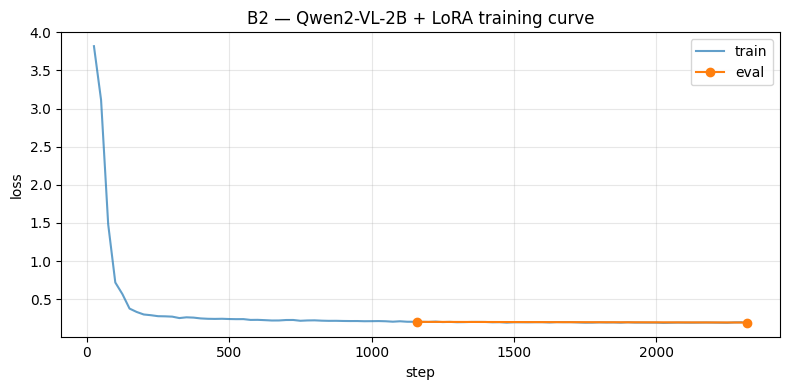

In [15]:
# load_best_model_at_end=True → trainer.model HIỆN TẠI là best checkpoint
adapter_dir = OUT_DIR / "adapter_best"
trainer.save_model(str(adapter_dir))
processor_b2.save_pretrained(str(adapter_dir))

# ── Verify save ────────────────────────────────────────────────────────────
saved = sorted(Path(adapter_dir).glob("*"))
total_mb = sum(f.stat().st_size for f in saved if f.is_file()) / 1024**2
print(f"✓ Best LoRA adapter saved → {adapter_dir}  ({total_mb:.1f} MB)")
for f in saved:
    if f.is_file():
        print(f"    {f.name}  ({f.stat().st_size/1024:.1f} KB)")

# Best eval_loss
best_eval = min((h["eval_loss"] for h in trainer.state.log_history
                 if "eval_loss" in h), default=None)
if best_eval is not None:
    print(f"  Best eval_loss : {best_eval:.4f}")

# Plot loss curve
hist = trainer.state.log_history
train_loss = [(h["step"], h["loss"]) for h in hist if "loss" in h and "eval_loss" not in h]
eval_loss  = [(h["step"], h["eval_loss"]) for h in hist if "eval_loss" in h]

if train_loss:
    fig, ax = plt.subplots(1, 1, figsize=(8, 4))
    s, l = zip(*train_loss); ax.plot(s, l, label="train", alpha=.7)
    if eval_loss:
        s, l = zip(*eval_loss); ax.plot(s, l, "o-", label="eval")
    ax.set_xlabel("step"); ax.set_ylabel("loss"); ax.legend(); ax.grid(alpha=.3)
    ax.set_title("B2 — Qwen2-VL-2B + LoRA training curve")
    fig.tight_layout(); plt.show()


### 7.5 Inference function & evaluate

In [16]:
# Re-enable cache for fast generation
model_b2.config.use_cache = True
model_b2.eval()

@torch.no_grad()
def run_b2_inference(data: List[Dict], batch_size: int = B2_INFER_BATCH,
                     desc: str = "B2") -> List[str]:
    preds: List[str] = []
    for i in tqdm(range(0, len(data), batch_size), desc=desc):
        chunk = data[i:i + batch_size]
        msgs_list = [build_messages(d, include_answer=False) for d in chunk]
        texts = [processor_b2.apply_chat_template(m, tokenize=False,
                                                   add_generation_prompt=True)
                 for m in msgs_list]
        image_inputs, _ = process_vision_info(msgs_list)
        inputs = processor_b2(text=texts, images=image_inputs,
                              padding=True, return_tensors="pt").to(DEVICE)
        gen = model_b2.generate(
            **inputs,
            max_new_tokens=B2_MAX_NEW_TOKENS,
            num_beams=B2_NUM_BEAMS,
            do_sample=False,
            pad_token_id=processor_b2.tokenizer.pad_token_id,
        )
        trimmed = [out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, gen)]
        out = processor_b2.batch_decode(trimmed, skip_special_tokens=True,
                                        clean_up_tokenization_spaces=False)
        preds.extend([t.strip().lower() for t in out])
    return preds

_smoke_b2 = run_b2_inference(val_data[:4], batch_size=1, desc="B2 smoke")
for d, p in zip(val_data[:4], _smoke_b2):
    print(f"Q: {d['question']!r}\n  GT: {d['answer']!r}\n  B2: {p!r}\n")

B2 smoke:   0%|          | 0/4 [00:00<?, ?it/s]

Q: 'Món ăn này phổ biến ở miền nào nhỉ?'
  GT: 'nam'
  B2: 'nam'

Q: 'Đây là loại món gì?'
  GT: 'khô'
  B2: 'khô'

Q: 'Theo bạn, nhân bánh mì thịt nằm ở đâu vậy?'
  GT: 'ở giữa'
  B2: 'ở giữa'

Q: 'Món này thường ăn khi nào?'
  GT: 'chiều'
  B2: 'chiều'



In [17]:
preds_b2_val  = run_b2_inference(val_data,  desc="B2 Val")
res_b2_val    = full_eval(preds_b2_val,  gts_val_vi,  tag="B2 Val")
res_b2_val["LLM Judge"] = run_llm_judge(preds_b2_val, gts_val_vi, qs_val_vi, tag="B2 Val")

preds_b2_test = run_b2_inference(test_data, desc="B2 Test")
res_b2_test   = full_eval(preds_b2_test, gts_test_vi, tag="B2 Test")
res_b2_test["LLM Judge"] = run_llm_judge(preds_b2_test, gts_test_vi, qs_test_vi, tag="B2 Test")

B2 Val:   0%|          | 0/589 [00:00<?, ?it/s]


── Eval [B2 Val] ─────────────────────────────


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


   Exact Match           : 0.9228
   Token F1 (Soft)       : 0.9296
   BLEU-1                : 0.9287
   BLEU-2                : 0.5607
   METEOR                : 0.6392
   ROUGE-L               : 0.9325
   BERTScore F1          : 0.9842
   Semantic Sim          : 0.9805
   LLM Judge             : (not run)
[WARN] OPENAI_API_KEY chưa set — bỏ qua LLM judge.


B2 Test:   0%|          | 0/586 [00:00<?, ?it/s]


── Eval [B2 Test] ─────────────────────────────


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


   Exact Match           : 0.9070
   Token F1 (Soft)       : 0.9180
   BLEU-1                : 0.9164
   BLEU-2                : 0.5430
   METEOR                : 0.6256
   ROUGE-L               : 0.9212
   BERTScore F1          : 0.9809
   Semantic Sim          : 0.9658
   LLM Judge             : (not run)
[WARN] OPENAI_API_KEY chưa set — bỏ qua LLM judge.


## 8. So sánh B1 vs B2

In [18]:
results_B = {
    "B1 (BLIP-2 ZS) Val"        : res_b1_val,
    "B1 (BLIP-2 ZS) Test"       : res_b1_test,
    "B2 (Qwen2-VL LoRA) Val"    : res_b2_val,
    "B2 (Qwen2-VL LoRA) Test"   : res_b2_test,
}
df_B = pd.DataFrame(results_B).T.apply(pd.to_numeric, errors="coerce").round(4)
print("=" * 80)
print(" MODEL B — RESULTS")
print("=" * 80)
df_B


 MODEL B — RESULTS


,Exact Match,Token F1 (Soft),BLEU-1,BLEU-2,METEOR,ROUGE-L,BERTScore F1,Semantic Sim,LLM Judge
B1 (BLIP-2 ZS) Val,0.0059,0.0627,0.0422,0.0164,0.0602,0.1384,0.6872,0.4459,NaN
B1 (BLIP-2 ZS) Test,0.0051,0.0645,0.0437,0.0168,0.0606,0.1442,0.6835,0.4539,NaN
B2 (Qwen2-VL LoRA) Val,0.9228,0.9296,0.9287,0.5607,0.6392,0.9325,0.9842,0.9805,NaN
B2 (Qwen2-VL LoRA) Test,0.9070,0.9180,0.9164,0.5430,0.6256,0.9212,0.9809,0.9658,NaN


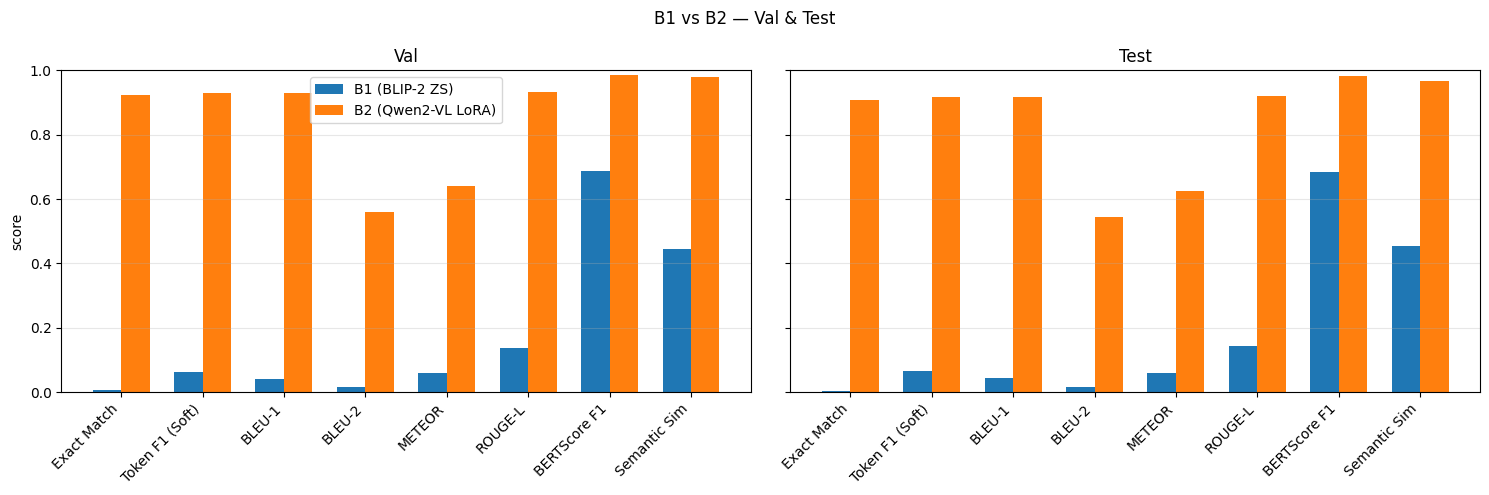

In [19]:
METRICS = ["Exact Match", "Token F1 (Soft)", "BLEU-1", "BLEU-2",
           "METEOR", "ROUGE-L", "BERTScore F1", "Semantic Sim"]
configs = [("B1 (BLIP-2 ZS)", res_b1_val, res_b1_test),
           ("B2 (Qwen2-VL LoRA)", res_b2_val, res_b2_test)]

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, split in zip(axes, ["Val", "Test"]):
    x = np.arange(len(METRICS)); w = 0.35
    for i, (name, val, test) in enumerate(configs):
        src = val if split == "Val" else test
        vals = [src.get(m) or 0 for m in METRICS]
        ax.bar(x + (i - 0.5) * w, vals, w, label=name)
    ax.set_xticks(x); ax.set_xticklabels(METRICS, rotation=45, ha="right")
    ax.set_title(split); ax.set_ylim(0, 1); ax.grid(alpha=.3, axis="y")
axes[0].set_ylabel("score"); axes[0].legend()
fig.suptitle("B1 vs B2 — Val & Test"); fig.tight_layout(); plt.show()

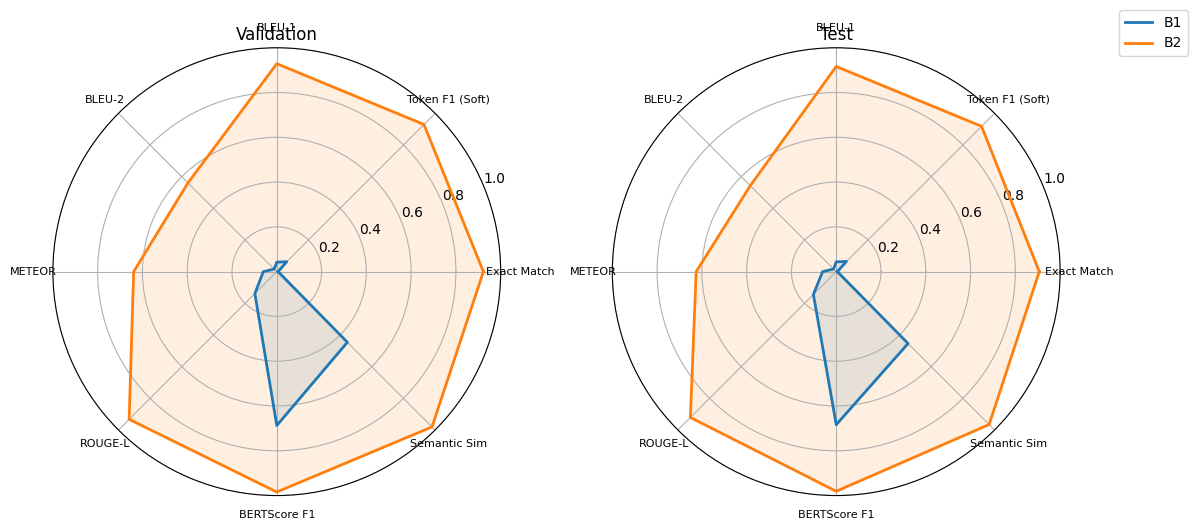

In [20]:
def radar(ax, vals_dict, title):
    angles = np.linspace(0, 2*np.pi, len(METRICS), endpoint=False).tolist()
    angles += angles[:1]
    for name, vals in vals_dict.items():
        v = [vals.get(m) or 0 for m in METRICS] + [vals.get(METRICS[0]) or 0]
        ax.plot(angles, v, label=name, linewidth=2)
        ax.fill(angles, v, alpha=0.12)
    ax.set_xticks(angles[:-1]); ax.set_xticklabels(METRICS, fontsize=8)
    ax.set_ylim(0, 1); ax.set_title(title); ax.grid(True)

fig, axes = plt.subplots(1, 2, figsize=(12, 6), subplot_kw=dict(polar=True))
radar(axes[0], {"B1": res_b1_val,  "B2": res_b2_val},  "Validation")
radar(axes[1], {"B1": res_b1_test, "B2": res_b2_test}, "Test")
axes[1].legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
fig.tight_layout(); plt.show()

In [21]:
print(f"{'Question':<42} {'GT':<14} {'B1':<22} {'B2':<22}")
print("-" * 102)
for d, p1, p2 in list(zip(test_data, preds_b1_test, preds_b2_test))[:10]:
    q = d["question"][:40]; gt = d["answer"][:12]
    print(f"{q:<42} {gt:<14} {p1[:20]:<22} {p2[:20]:<22}")

Question                                   GT             B1                     B2                    
------------------------------------------------------------------------------------------------------
Cho mình hỏi, một tô phở thường có bao n   năm lát        nhiều như bạn muốn     năm lát               
Bạn có thể cho biết, món này thuộc nhóm    khô            đó là nhóm những ngư   khô                   
Món trong ảnh là gì?                       phở            đồng cỏ khói quan gi   bún bò                
Cho mình hỏi, người ta thường ăn món này   cả ngày Tết    ♪ vào buổi sáng, buổ   sáng và tối           
Vỏ bánh ướt nằm ở đâu nhỉ?                 bên ngoài      trong miệng ra ra ra   bên ngoài             
Có thịt trong món này không nhé?           có             đúng vậy, có hình tư   có                    
Theo bạn, một đĩa bánh ướt có bao nhiêu    nhiều lớp      nó phụ thuộc vào đườ   nhiều lớp             
Theo bạn, món này có phải đồ ăn đường ph   có             & xuất 

## 9. Persist results JSON (cho VQA_Demo_Compare)

In [22]:
out = {
    "B1": {"val": res_b1_val,  "test": res_b1_test,
           "preds_val": preds_b1_val,  "preds_test": preds_b1_test,
           "model": MODEL_B1, "strategy": "translate Vi<->En (MarianMT)"},
    "B2": {"val": res_b2_val,  "test": res_b2_test,
           "preds_val": preds_b2_val,  "preds_test": preds_b2_test,
           "model": MODEL_B2, "strategy": "direct Vietnamese, 4-bit + LoRA"},
    "questions_val":  qs_val_vi,
    "questions_test": qs_test_vi,
    "gts_val":        gts_val_vi,
    "gts_test":       gts_test_vi,
}
out_path = RESULTS_DIR / "results_B.json"
with open(out_path, "w", encoding="utf-8") as f:
    json.dump(out, f, ensure_ascii=False, indent=2, default=lambda x: None)
print(f"✓ Saved → {out_path}")
print(f"   ({out_path.stat().st_size/1024:.1f} KB)")

✓ Saved → /kaggle/working/results/results_B.json
   (380.1 KB)


In [26]:
import zipfile
from pathlib import Path

out_zip = Path("/kaggle/working/vqa_b_output.zip")
if out_zip.exists():
    out_zip.unlink()

SRC = [
    Path("/kaggle/working/results"),
    Path("/kaggle/working/checkpoints/qwen2vl_lora_b2/adapter_best"),
]

n_files = 0
with zipfile.ZipFile(out_zip, "w", zipfile.ZIP_DEFLATED) as zf:
    for src in SRC:
        if not src.exists():
            print(f"[SKIP] {src} không tồn tại")
            continue
        for p in src.rglob("*"):
            if p.is_file():
                zf.write(p, p.relative_to("/kaggle/working"))
                n_files += 1

mb = out_zip.stat().st_size / 1024**2
print(f"✓ Done: {out_zip}  ({mb:.1f} MB, {n_files} files)")

✓ Done: /kaggle/working/vqa_b_output.zip  (17.4 MB, 9 files)
